<a href="https://colab.research.google.com/github/kishoredage/letter_recognizer/blob/main/ARIMA_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [34]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df =pd.read_csv(url, header=0, index_col=0, parse_dates = True)

In [35]:
#time based split
train = df.iloc[:120]
test = df.iloc[120:]

In [36]:
#Build ARIMA model - (p=1, d=1`, q=1) as starting point
model = ARIMA(train['Passengers'], order=(1,1,1))
fitted = model.fit()

In [37]:
#Forecast - predict same number of steps as test set
forecast = fitted.forecast(steps=len(test))

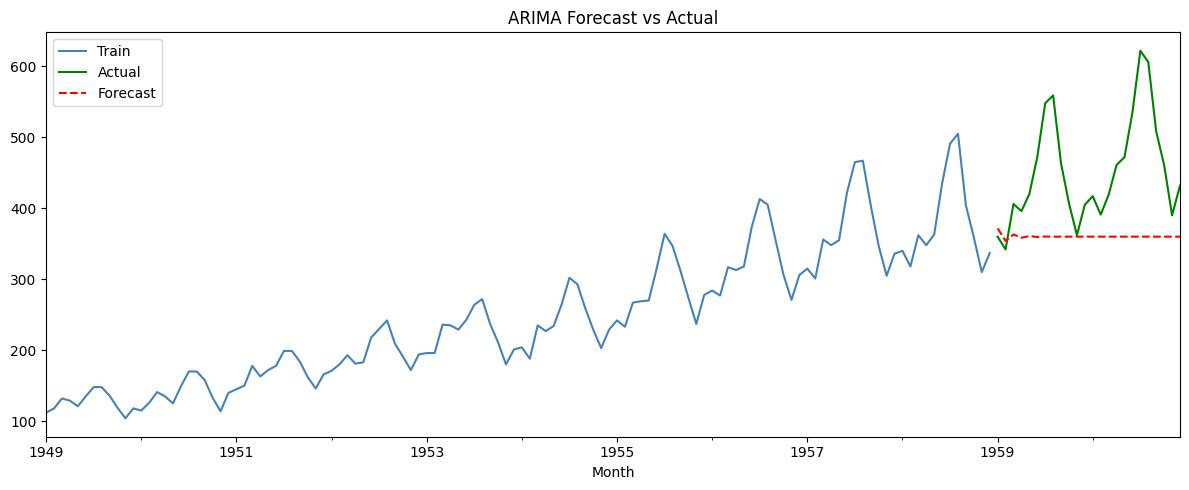

In [38]:
#plot Actual vs predicted
plt.figure(figsize=(12,5))
train['Passengers'].plot(label='Train',color='steelblue')
test['Passengers'].plot(label='Actual',color='green')
forecast.plot(label='Forecast',color='red',linestyle='--')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
#Evaluate
mae = mean_absolute_error(test['Passengers'],forecast)
print(f"MAE: {mae:.2f}")
print(f"This means on average our forecast is off by {mae:.0f} passengers")

MAE: 93.90
This means on average our forecast is off by 94 passengers


In [40]:
#using SARIMA (seasonal ARIMA)
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [41]:
model_sarima= SARIMAX(train['Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12)) #12 = Yearly pattern


In [42]:
fitted = model_sarima.fit(disp=False)
forecast_sarima = fitted.forecast(steps=len(test))

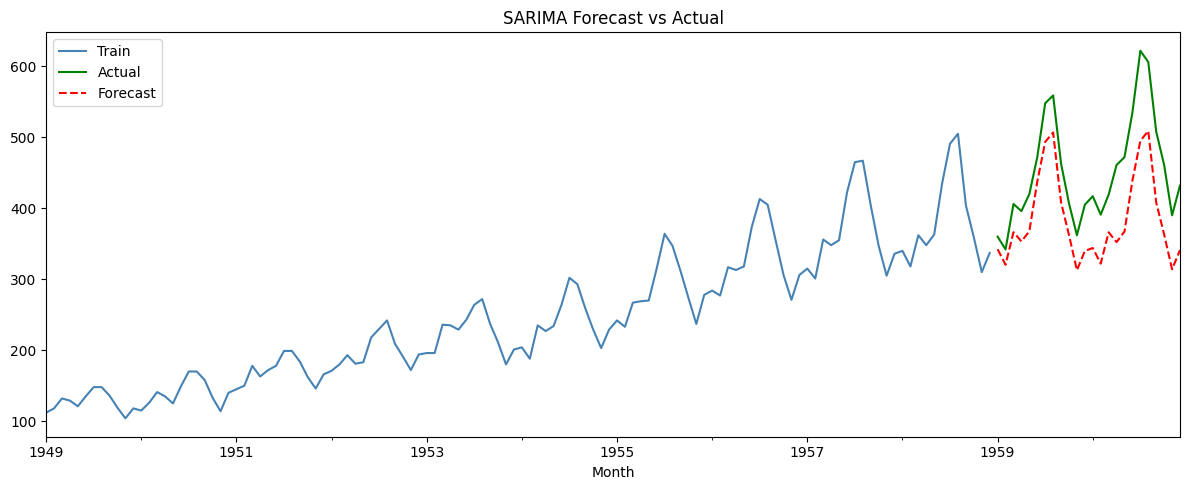

In [45]:
plt.figure(figsize=(12,5))
train['Passengers'].plot(label='Train', color='steelblue')
test['Passengers'].plot(label='Actual',color='green')
forecast_sarima.plot(label='Forecast',color='red',linestyle ='--')
plt.title('SARIMA Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
mae = mean_absolute_error(test['Passengers'],forecast_sarima)
print(f"SARIMA MAE {mae:.2f}")

SARIMA MAE 67.59


In [46]:
print(df.columns)

Index(['Passengers'], dtype='object')
